# 📘 Krones Vision AI Challenge — Sample Training Notebook
### ✅ MobileNetV3-Small Baseline (with ROI Cropping + ONNX Export)

This notebook provides a clean, step-by-step baseline training pipeline for the competition:

✅ Step-by-step structured workflow  
✅ ROI extraction from COCO annotations  
✅ MobileNetV3-Small baseline classifier  
✅ Training + validation metrics  
✅ ONNX export for seamless evaluation  
✅ Clear, beginner-friendly explanations  

---


## ⚠️ Important Notes on Kaggle Environment Requirements

### 🔌 Internet Access & Pretrained Weights (Optional but Recommended)

This notebook uses **pretrained ImageNet weights** (e.g. for MobileNetV3-Small) by default.  
These weights are **downloaded automatically** the first time the model is created.

To use pretrained weights:
- **Internet must be enabled** in the Kaggle notebook  
  *(Notebook Settings → Internet → ON)*
- **Your Kaggle account must be phone‑verified**

**Phone verification is optional**, but if it is **not completed**:
- Pretrained weights **cannot be downloaded**
- The model must be trained **from scratch**
- Training may converge slower and achieve lower performance

✅ Once pretrained weights are downloaded, they are cached and do not need to be downloaded again.

> 🔒 **Privacy Note**  
> Phone verification is a **Kaggle platform requirement**, **not** a requirement of this competition.  
> The competition hosts **do not receive**, see, or have access to any personal or phone‑related information.

---

### ⚡ Hardware Accelerators (GPU / TPU)

If you want to train using **Kaggle’s built‑in hardware accelerators** instead of your own machine:

- **Phone verification is required by Kaggle**
- Without verification:
  - **GPU and TPU are unavailable**
  - Training is limited to **CPU only**
- TPU access is **not possible** without successful phone verification

✅ With phone verification enabled, accelerators can be selected via  
*Notebook Settings → Accelerator*.

> 🔍 Summary:  
> Phone verification is **only enforced by Kaggle** to enable internet access and shared compute resources.  
> You can still participate without it, but with **CPU‑only training** and **no pretrained weight downloads**.


---

### 🔒 Competition Requirement
You may modify **any part** of this notebook — **except**:

🔥 The **ONNX export must remain functional**, as it is required for running your model in the **Evaluation Notebook**.

# ✅ Step 1 — Check Your Hardware

We verify the environment so you know:

- Whether a GPU is available  
- CPU details  
- Expected performance characteristics  

This helps you understand how your training will behave on Kaggle.

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
!cat /proc/cpuinfo | head -n 20

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 79
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2199.998
cache size	: 56320 KB
physical id	: 0
siblings	: 4
core id		: 0
cpu cores	: 2
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch pti ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm rdseed adx smap xsaveopt arat md_clear arch_capabilities


# ✅ Step 2 — Import Libraries & Configure Paths

We import:

- PyTorch (training)
- Torchvision (model + transforms)
- Pandas (CSV loading)
- COCO JSON parser
- Metrics (accuracy, AUC, F1,…)

We also set the dataset paths inside the Kaggle environment.

In [3]:
# =========================================================
# Imports
# =========================================================

import os
import json
import time
from datetime import datetime

import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# PyTorch (deep learning framework)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

# Metrics from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

# =========================================================
# Dataset Paths — IMPORTANT:
# Kaggle mounts your dataset here automatically.
# =========================================================
DATASET_DIR = "/kaggle/input/competitions/1st-krones-vision-ai-challenge"
TRAIN_IMAGE_DIR = os.path.join(DATASET_DIR, "train_images")  # Folder with train images
TRAIN_CSV = os.path.join(DATASET_DIR, "train.csv")           # CSV containing class label for each image
TRAIN_JSON = os.path.join(DATASET_DIR, "train_annotations.json")  # COCO Annotations (including ROI)

# Folder to store logs, checkpoints, ONNX model
ARTIFACTS_DIR = "training_artifacts"

print("Dataset directory exists:", os.path.exists(DATASET_DIR))
print("Train images:", os.path.exists(TRAIN_IMAGE_DIR))
print("Train CSV:", os.path.exists(TRAIN_CSV))
print("Annotations JSON:", os.path.exists(TRAIN_JSON))

Dataset directory exists: True
Train images: True
Train CSV: True
Annotations JSON: True


# ✅ Step 3 — Load ROI (Region of Interest) From COCO JSON

The dataset includes COCO-style annotations.

- Category **22** marks the bounding box around the bottle region.
- We generate a dictionary:  
  **filename → ROI bounding box [x, y, w, h]**

Images without ROI are simply used uncropped.

In [4]:
def load_roi_map(annotation_file):
    """
    Loads the COCO annotation file and extracts ROI bounding boxes.
    Category_id == 22 contains the bottle ROI bounding boxes.
    Returns: { filename : [x, y, w, h] }
    """
    
    with open(annotation_file, "r") as f:
        data = json.load(f)

    # Map image_id -> filename for quick lookup
    img_lookup = {img["id"]: img["file_name"] for img in data["images"]}
    roi_map = {}

    # Iterate over all annotations
    for ann in data["annotations"]:
        if ann.get("category_id") == 22:         # ROI category
            fname = img_lookup[ann["image_id"]]  # find the filename
            roi_map[fname] = ann["bbox"]         # store bounding box

    print(f"✅ Loaded {len(roi_map)} ROI regions.")
    return roi_map

print("✅ ROI loader function defined successfully")

✅ ROI loader function defined successfully


# ✅ Step 4 — Build the PyTorch Dataset (with ROI Cropping)

The dataset:

- Loads image  
- Applies ROI cropping (if available)  
- Applies augmentations for training  
- Normalizes using ImageNet stats  
- Returns a tensor + label  

This works with both CPU & GPU.

In [5]:
class RoiDataset(Dataset):
    """
    PyTorch Dataset:
    - Loads image
    - Applies ROI cropping (if available)
    - Applies augmentations for training
    - Normalizes using ImageNet statistics
    """

    def __init__(self, df, roi_map, image_dir, train=True, image_size=(512, 512)):
        self.df = df
        self.roi_map = roi_map
        self.image_dir = image_dir
        self.train = train
        self.image_size = image_size

        # Augmentations for training
        self.train_tf = transforms.Compose([
            transforms.Resize(image_size),
            transforms.RandomHorizontalFlip(),         # flip for robustness
            transforms.ColorJitter(0.2,0.2,0.2,0.1),   # slight color changes
            transforms.RandomAffine(0, translate=(0.1,0.1), fill=0),  # shift image
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])  # ImageNet
        ])

        # Only resize + normalize for validation
        self.val_tf = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Load row (filename + label)
        row = self.df.iloc[idx]
        fname = row["image_id"]
        target = torch.tensor(row["target"], dtype=torch.float32)

        # Load image
        img = Image.open(os.path.join(self.image_dir, fname)).convert("RGB")

        # Crop ROI if available
        if fname in self.roi_map:
            x, y, w, h = self.roi_map[fname]
            img = img.crop((x, y, x + w, y + h))

        # Choose transforms based on training/validation mode
        img = self.train_tf(img) if self.train else self.val_tf(img)

        return img, target

print("✅ RoiDataset class defined successfully")

✅ RoiDataset class defined successfully


# ✅ Step 5 — Create the Model (MobileNetV3‑Small)

We use:

- ImageNet pretrained weights  
- Replace last layer with a **single binary output**  
- Predicts:  
  - `0` → Reusable  
  - `1` → Not Reusable  

In [6]:
def create_model():
    """
    Loads a MobileNetV3-Small model with pretrained ImageNet weights.
    Replaces the classification head with a single binary output.
    """
    model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
    
    # Replace final FC layer with binary classifier
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, 1)

    return model

print("✅ Model creation function defined successfully")

✅ Model creation function defined successfully


# ✅ Step 6 — Training Loop

This function handles:

✅ Forward pass  
✅ Loss calculation  
✅ Backpropagation  
✅ Mixed Precision (AMP)  
✅ TQDM progress indicator  

In [7]:
def train_one_epoch(model, loader, optimizer, epoch, criterion, scaler, device):
    """
    Performs one training epoch:
    - Forward pass
    - Loss computation
    - Backpropagation (with mixed precision)
    """
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc=f"Training Epoch {epoch}")

    for imgs, targets in pbar:
        imgs, targets = imgs.to(device), targets.to(device).unsqueeze(1)

        optimizer.zero_grad()

        # Mixed Precision forward pass
        with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
            logits = model(imgs)
            loss = criterion(logits, targets)

        # Backward pass + update weights
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

    avg_loss = total_loss / len(loader.dataset)
    print(f"✅ Epoch {epoch} — Avg Loss: {avg_loss:.4f}")
    return avg_loss


print("✅ Training loop function defined successfully")

✅ Training loop function defined successfully


# ✅ Step 7 — Validation Loop

Computes model performance using:

- ✅ Accuracy  
- ✅ AUC  
- ✅ F1-score  
- ✅ Precision  
- ✅ Recall  

In [8]:
def validate(model, loader, threshold=0.5, device="cuda"):
    """
    Runs validation:
    - Computes probabilities using sigmoid()
    - Applies threshold to convert to class labels
    - Computes accuracy, AUC, F1, precision, recall
    """
    model.eval()
    all_targets, all_probs = [], []

    pbar = tqdm(loader, desc="Validating")

    with torch.no_grad():
        for imgs, targets in pbar:
            imgs = imgs.to(device)
            targets = targets.to(device).unsqueeze(1)

            # Forward pass in mixed precision
            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                logits = model(imgs)

            probs = torch.sigmoid(logits)  # convert logits → probabilities

            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    # Convert probabilities to binary predictions
    bin_preds = [1 if p >= threshold else 0 for p in all_probs]

    return {
        "acc": accuracy_score(all_targets, bin_preds),
        "auc": roc_auc_score(all_targets, all_probs),
        "f1": f1_score(all_targets, bin_preds),
        "precision": precision_score(all_targets, bin_preds),
        "recall": recall_score(all_targets, bin_preds),
    }

print("✅ Validation function defined successfully")

✅ Validation function defined successfully


# ✅ Step 8 — Load the data and initialize the dataloaders

This:

1. Loads ROI map  
2. Reads CSV labels  
3. Splits into train/validation  
4. Initializes dataloaders

In [9]:
# Create output folder
os.makedirs(os.path.join(os.getcwd(), ARTIFACTS_DIR), exist_ok=True)
run_name = "run_" + datetime.now().strftime("%Y%m%d_%H%M")
run_dir = os.path.join(ARTIFACTS_DIR, run_name)
os.makedirs(run_dir, exist_ok=True)

# Hyperparameters
image_size = (512, 512)
batch_size = 32
workers = 4

# Determine device (GPU preferred)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Using device:", device)

# Load ROI map
roi_map = load_roi_map(TRAIN_JSON)

# Load CSV labels
df = pd.read_csv(TRAIN_CSV)

# Optional: Limit dataset for fast testing/experimentation. (Set to None for full run).
LIMIT = 1000

if LIMIT is not None:
    # Subsamples the dataframe
    df = df.sample(LIMIT, random_state=42).reset_index(drop=True)

# Create train/validation split
train_df, val_df = train_test_split(df, test_size=0.1,
                                    stratify=df["target"], random_state=42)

# Build datasets + dataloaders
train_ds = RoiDataset(train_df, roi_map, TRAIN_IMAGE_DIR, train=True, image_size=image_size)
val_ds = RoiDataset(val_df, roi_map, TRAIN_IMAGE_DIR, train=False, image_size=image_size)

# Build dataloaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True if torch.cuda.is_available() else False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True if torch.cuda.is_available() else False)

✅ Using device: cpu
✅ Loaded 35342 ROI regions.


# ✅ Step 9 — Dataset Review & Visualization
Always visualize your data! Let's check a few crops out of the validation data stream to ensure our bounding boxes and augmentations processed correctly.

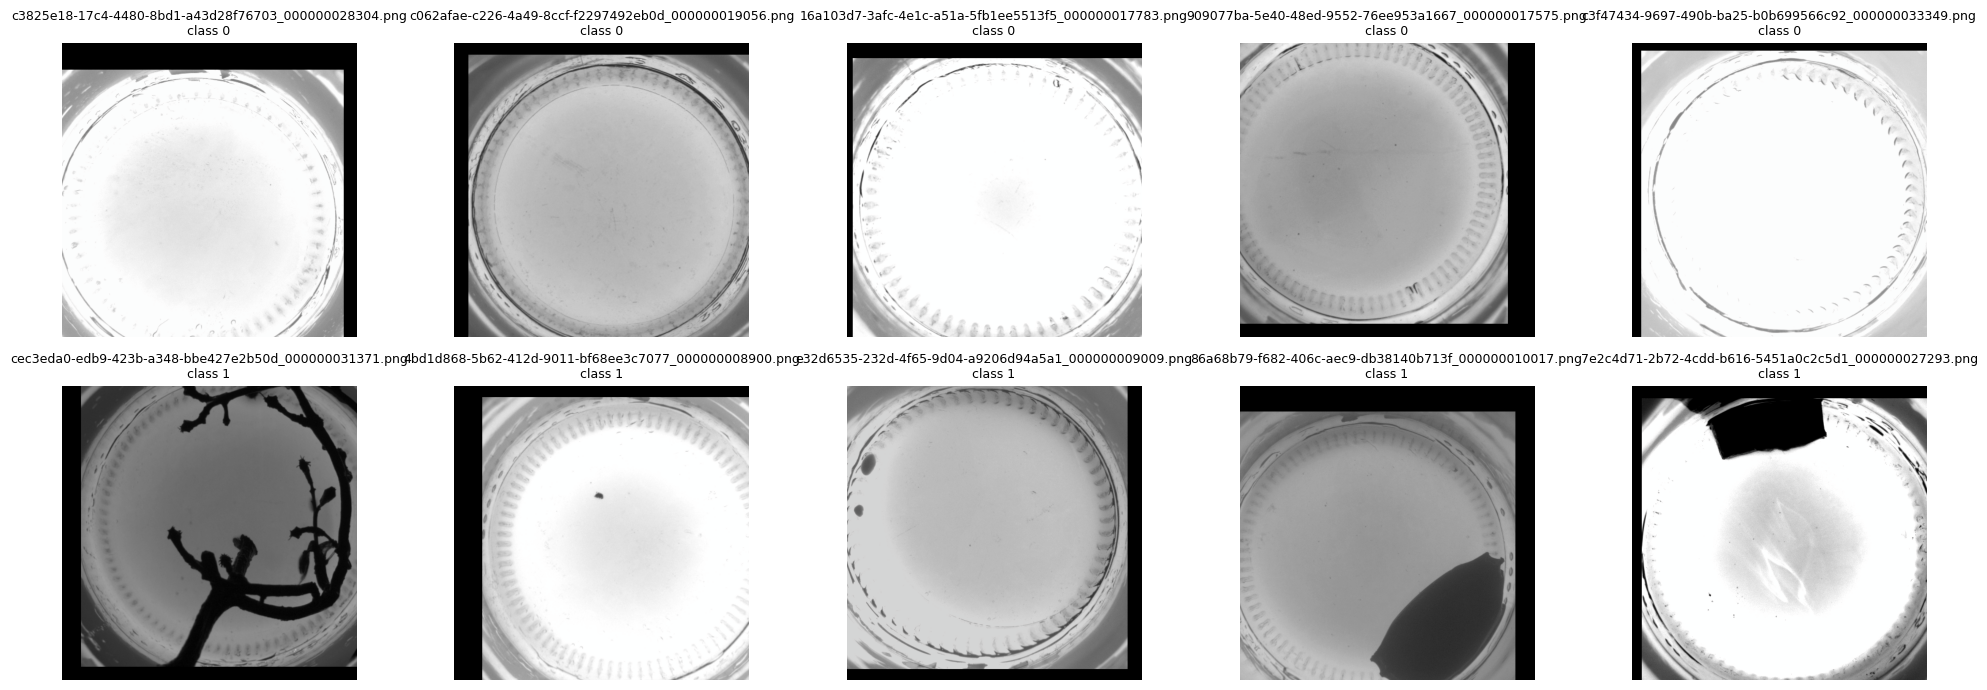

In [10]:
def show_samples(dataset, num_per_class=5):
    class_samples = {0: [], 1: []}

    # Collect samples: (image_tensor, label, filename)
    for idx in range(len(dataset)):
        img, label = dataset[idx]
        fname = dataset.df.iloc[idx]["image_id"]  # retrieve filename

        label = int(label.item())
        if len(class_samples[label]) < num_per_class:
            class_samples[label].append((img, fname))
        
        if len(class_samples[0]) >= num_per_class and len(class_samples[1]) >= num_per_class:
            break

    # Plot
    fig, ax = plt.subplots(2, num_per_class, figsize=(num_per_class * 4, 7))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for cls in [0, 1]:
        for i, (img, fname) in enumerate(class_samples[cls]):
            img_np = img.permute(1, 2, 0).numpy()
            img_np = std * img_np + mean
            img_np = np.clip(img_np, 0, 1)

            ax[cls, i].imshow(img_np)
            ax[cls, i].set_title(f"{fname}\nclass {cls}", fontsize=9)
            ax[cls, i].axis("off")

    plt.tight_layout()
    plt.show()


show_samples(train_ds)

# ✅ Step 10 — Running the full training pipeline

1. Trains for `num_epochs` epochs  
2. Generates the artifacts in `training_artifacts/`:
   - `best_model.pth`
   - `latest_model.pth`
   - `model.onnx` ✅ required

In [11]:
# Initialize model + optimizer + scheduler
model = create_model().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
scaler = torch.amp.GradScaler(enabled=(device=="cuda"))

best_auc = 0.0

# -------------------------
# Training Loop
# -------------------------
num_epochs= 1
for epoch in range(1, num_epochs + 1):
    train_one_epoch(model, train_loader, optimizer, epoch, criterion, scaler, device)
    metrics = validate(model, val_loader, threshold=0.5, device=device)
    scheduler.step()

    print(f"Epoch {epoch} — AUC: {metrics['auc']:.4f} | F1: {metrics['f1']:.4f}")

    # Save best checkpoint
    if metrics["auc"] > best_auc:
        best_auc = metrics["auc"]
        torch.save(model.state_dict(), os.path.join(run_dir, "best_model.pth"))
        print("✅ New Best Model Saved!")

    # Always save latest checkpoint
    torch.save(model.state_dict(), os.path.join(run_dir, "latest_model.pth"))

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 88.2MB/s]
Training Epoch 1: 100%|██████████| 29/29 [02:02<00:00,  4.23s/it, Loss=0.4163]


✅ Epoch 1 — Avg Loss: 0.5585


Validating: 100%|██████████| 4/4 [00:05<00:00,  1.39s/it]


Epoch 1 — AUC: 0.6925 | F1: 0.1875
✅ New Best Model Saved!


## ✅ Step 11 — Install ONNXScript (if not already installed)


For evaluation (as shown in the **starter evaluation notebook**), the model **must be provided in ONNX format**.

- If you **train the model in Kaggle**, you may install **ONNXScript** and export to ONNX directly *(requires internet access)*.
- If you **train outside Kaggle** or prefer to use your **own hardware**, you can export the model to **ONNX yourself** and then **upload the `.onnx` file to Kaggle**.

✅ Either approach is fine — the key requirement is having a **model in ONNX format for evaluation**.

In [12]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 11.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 8.4 MB/s eta 0:00:00


# ✅ Step 12 — Exporting the Model to ONNX Format (Required!)

Your model MUST be exported to ONNX so it can be evaluated
in the Official Evaluation Notebook.

⚠️ Do not remove this step. 


You may see several **warnings** during export (e.g., about missing type
annotations or internal PyTorch exporter messages).  


✅ **If you see `Saved ONNX model to ...` the export was successful.**

In [13]:
def export_to_onnx(model, image_size, save_path):
    """
    Exports the trained PyTorch model to ONNX format.
    Required for the official evaluation notebook.
    """
    
    model.eval()

    # Dummy input needed for ONNX tracing
    dummy = torch.randn(1, 3, image_size[0], image_size[1]).to(next(model.parameters()).device)

    torch.onnx.export(
        model, dummy, save_path,
        input_names=["input"],     # names used in ONNX Runtime
        output_names=["logits"],
        opset_version=18
    )

    print(f"✅ Saved ONNX model to {save_path}")

# Export final ONNX model
export_to_onnx(model, image_size, os.path.join(run_dir, "model.onnx"))

W0423 06:52:46.245000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0423 06:52:46.247000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0423 06:52:46.250000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0423 06:52:46.252000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✅ Saved ONNX model to training_artifacts/run_20260423_0646/model.onnx
